# 2. Gas solubility

<a href="https://colab.research.google.com/github/jmoortgat/GasBrineBench/blob/main/notebooks/02_gas_solubility.ipynb" target="_blank" rel="noopener noreferrer"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>


`solubility.csv`: the dissolved gas in mol per kg of water (`solubility_molality`; its mole-fraction sibling carries the same information).
For each gas, three views of the **pure-water** data:

* (a) solubility against pressure, one colour/marker per temperature bin, with the median trend of each bin and the stated uncertainty
  where a source gave one (13 % of the rows);
* (b) the same points coloured by **source**: spread between colours at the same state is the disagreement between laboratories;
* (c) solubility against temperature at fixed pressure windows.

Then the salting-out trend: solubility against salt molality, at fixed pressure windows. Only the default view is used, so hydrate-regime
and liquid-liquid points are not mixed into gas solubility.

> **Running on Google Colab?** Click the badge above and run the cells; nothing needs to be installed. The first code cell detects
> Colab, clones the repository into `/content/GasBrineBench`, checks that pandas, numpy and matplotlib are present (Colab already has them)
> and changes into `notebooks/`, so everything after it works as on a local checkout. Locally the cell does nothing but confirm the layout.
> To use a fork or a branch, set `GBB_REPO_URL` and `GBB_BRANCH` before the cell runs.

In [1]:
# --- Colab / local bootstrap ---------------------------------------------------------------------------------
# On Colab this cell clones the repository and installs anything missing; on a local checkout it only confirms the layout.
# Re-running it is safe.
import os, subprocess, sys
from pathlib import Path

REPO_URL = os.environ.get("GBB_REPO_URL", "https://github.com/jmoortgat/GasBrineBench.git")
BRANCH = os.environ.get("GBB_BRANCH", "main")
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB or os.environ.get("GBB_FORCE_BOOTSTRAP"):
    REPO_DIR = Path("/content/GasBrineBench") if IN_COLAB else Path(os.environ.get("GBB_CLONE_DIR", "GasBrineBench_clone")).resolve()
    if not REPO_DIR.exists():
        print(f"cloning {REPO_URL} ({BRANCH}) into {REPO_DIR}")
        subprocess.check_call(["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, str(REPO_DIR)])
    else:
        print(f"repository already cloned at {REPO_DIR}")
    missing = []
    for pkg, mod in [("pandas", "pandas"), ("numpy", "numpy"), ("matplotlib", "matplotlib")]:
        try:
            __import__(mod)
        except ImportError:
            missing.append(pkg)
    if missing:
        print("pip install -q", " ".join(missing))
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    os.chdir(REPO_DIR / "notebooks")
    print("cwd =", os.getcwd())
else:
    print("local environment: using the existing checkout")

local environment: using the existing checkout


In [2]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")
HERE = pathlib.Path.cwd()
ROOT = HERE if (HERE / "gasbrinebench").exists() else HERE.parent
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT / "notebooks"))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import gasbrinebench as gbb
from gasbrinebench.vocab import DEFAULT_EXCLUDED_FLAGS
import gbb_viz as V
V.style()
# default view (what a benchmark user scores) and the view that also keeps rows without a stated pressure
df = gbb.load()
dfp = gbb.load(exclude_flags=tuple(f for f in DEFAULT_EXCLUDED_FLAGS if f != "pressure-unstated"))
dfall = gbb.load(exclude_tags=None, exclude_flags=None)
print(f"{len(dfall):,} rows in total, {len(df):,} in the default view, gasbrinebench {gbb.__version__}")

26,815 rows in total, 23,090 in the default view, gasbrinebench 1.2.0


In [3]:
sol = df[(df.property == "solubility_molality")]
pure = sol[sol.total_molality == 0]
GASES = ["co2", "ch4", "h2", "n2", "o2", "c2h6", "c3h8"]
print(pure.groupby("gas").agg(rows=("value", "size"), sources=("source", "nunique"), T_min=("T_K", "min"), T_max=("T_K", "max"), P_max=("P_bar", "max")).round(1))

def pressure_windows(g, n=4):
    q = np.quantile(g.P_bar, np.linspace(0.12, 0.88, n))
    return [(p * 0.88, p * 1.12) for p in q]

def gas_figure(gas):
    g = pure[pure.gas == gas]
    fig, ax = plt.subplots(1, 3, figsize=(18, 5.3))
    V.isotherms(ax[0], g); V.lab(ax[0], "P [bar]", "dissolved gas [mol/kg water]", f"(a) {V.GAS_LABEL[gas]}")
    V.by_source(ax[1], g); V.lab(ax[1], "P [bar]", "dissolved gas [mol/kg water]", "(b)")
    for k, (lo, hi) in enumerate(pressure_windows(g)):
        w = g[(g.P_bar >= lo) & (g.P_bar <= hi)]
        if len(w) < 3: continue
        ax[2].scatter(w.T_K, w.value, s=30, color=V.WONG[(k + 1) % 7], marker=V.MARKERS[k], edgecolor="black", linewidth=0.5, alpha=0.85,
                      label=f"{np.sqrt(lo * hi):.0f} bar (n={len(w)})")
        tx, ty = V.trend(w.T_K, w.value, nbins=7, logx=False)
        if len(tx): ax[2].plot(tx, ty, color=V.WONG[(k + 1) % 7], ls=V.LINESTYLES[k % 5])
    ax[2].set_yscale("log"); ax[2].legend(loc="best"); V.lab(ax[2], "T [K]", "dissolved gas [mol/kg water]", "(c)")
    plt.tight_layout(); plt.show()

      rows  sources  T_min  T_max   P_max
gas                                      
c2h6   100        7  274.6  345.6  1000.0
c3h8   187        7  273.2  427.6   206.8
ch4    852       36  273.9  633.2  1972.6
co2   1228       37  273.2  623.2  3500.0
h2     181       11  273.2  636.1  1013.3
n2     205       14  273.7  636.5  1013.2
o2     160       11  273.7  473.2    30.0


## CO2 in water

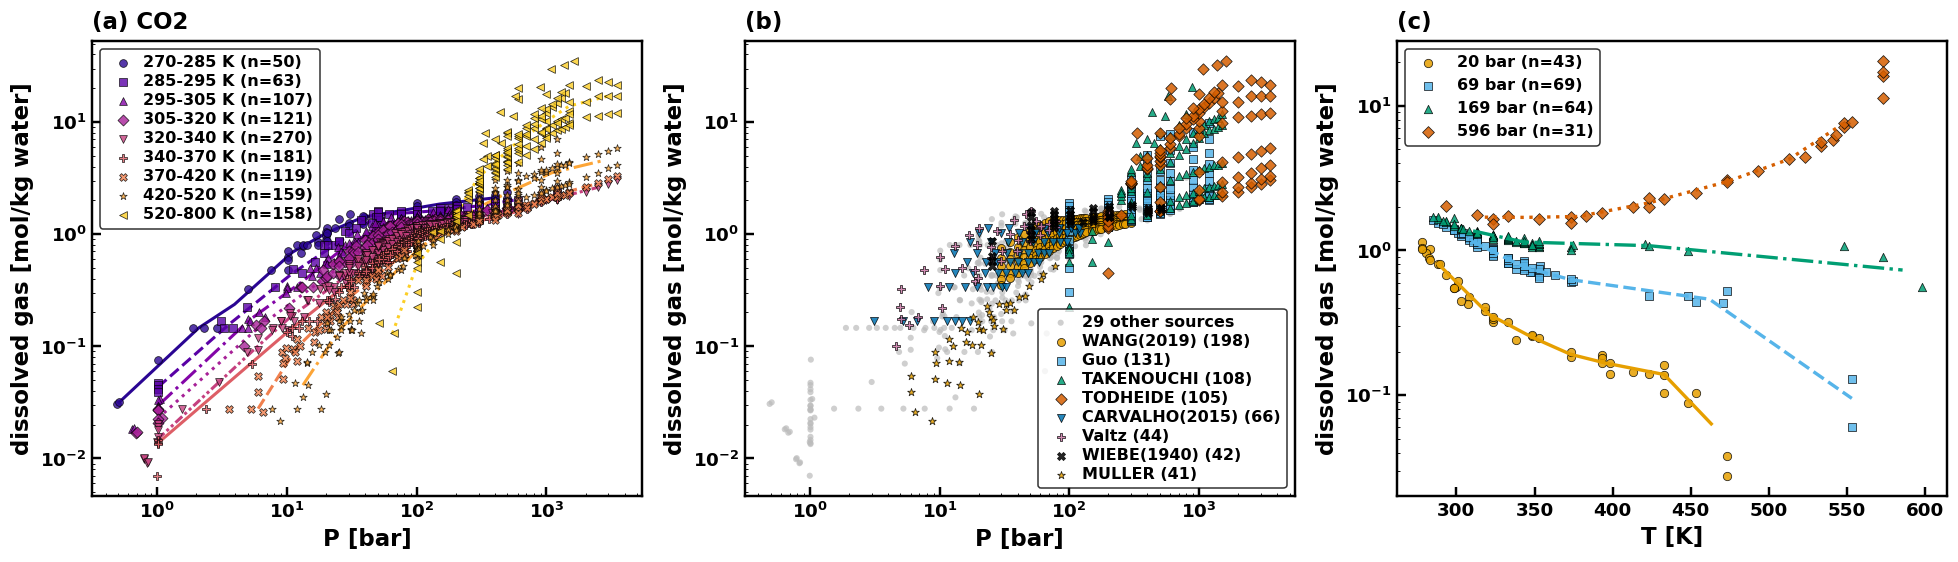

In [4]:
gas_figure("co2")

## CH4 in water

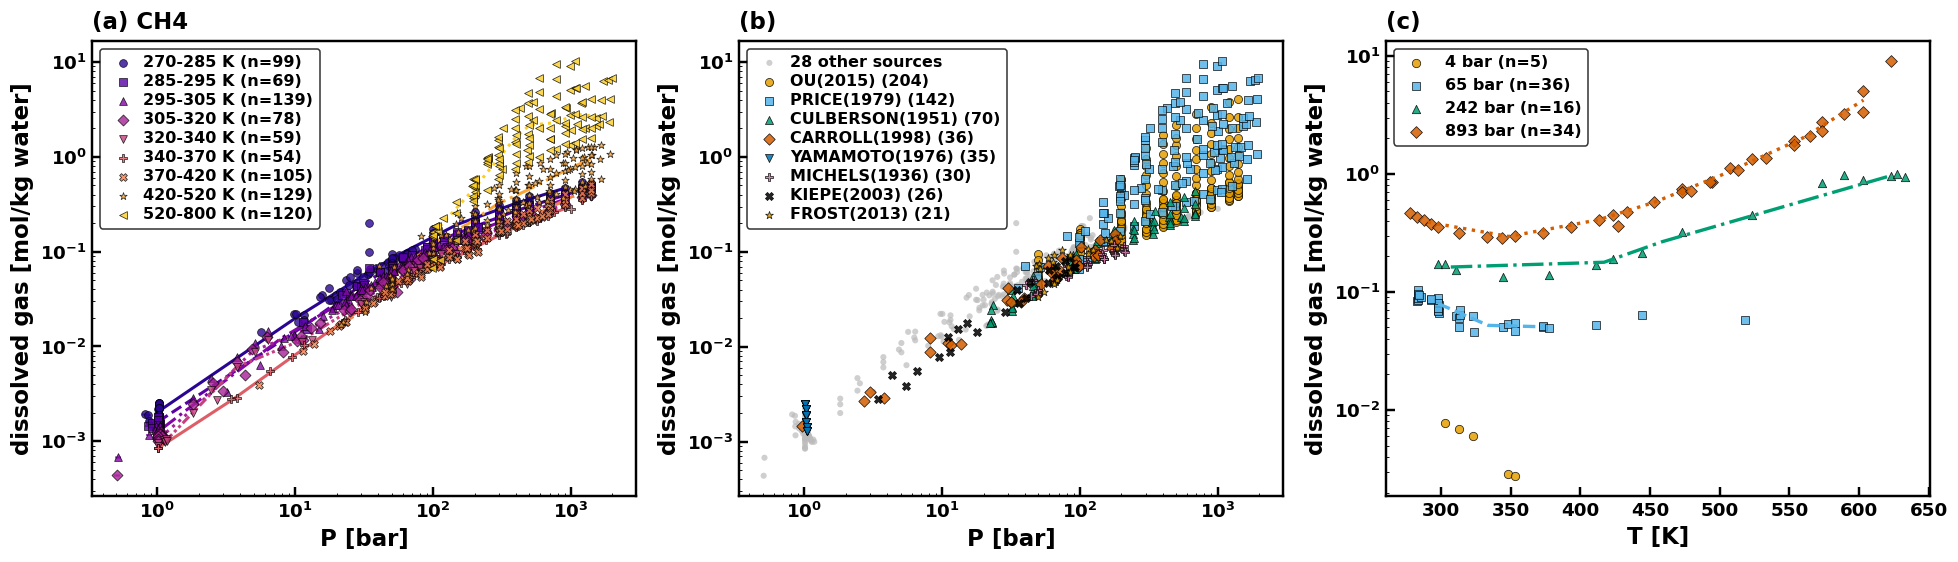

In [5]:
gas_figure("ch4")

## H2 in water

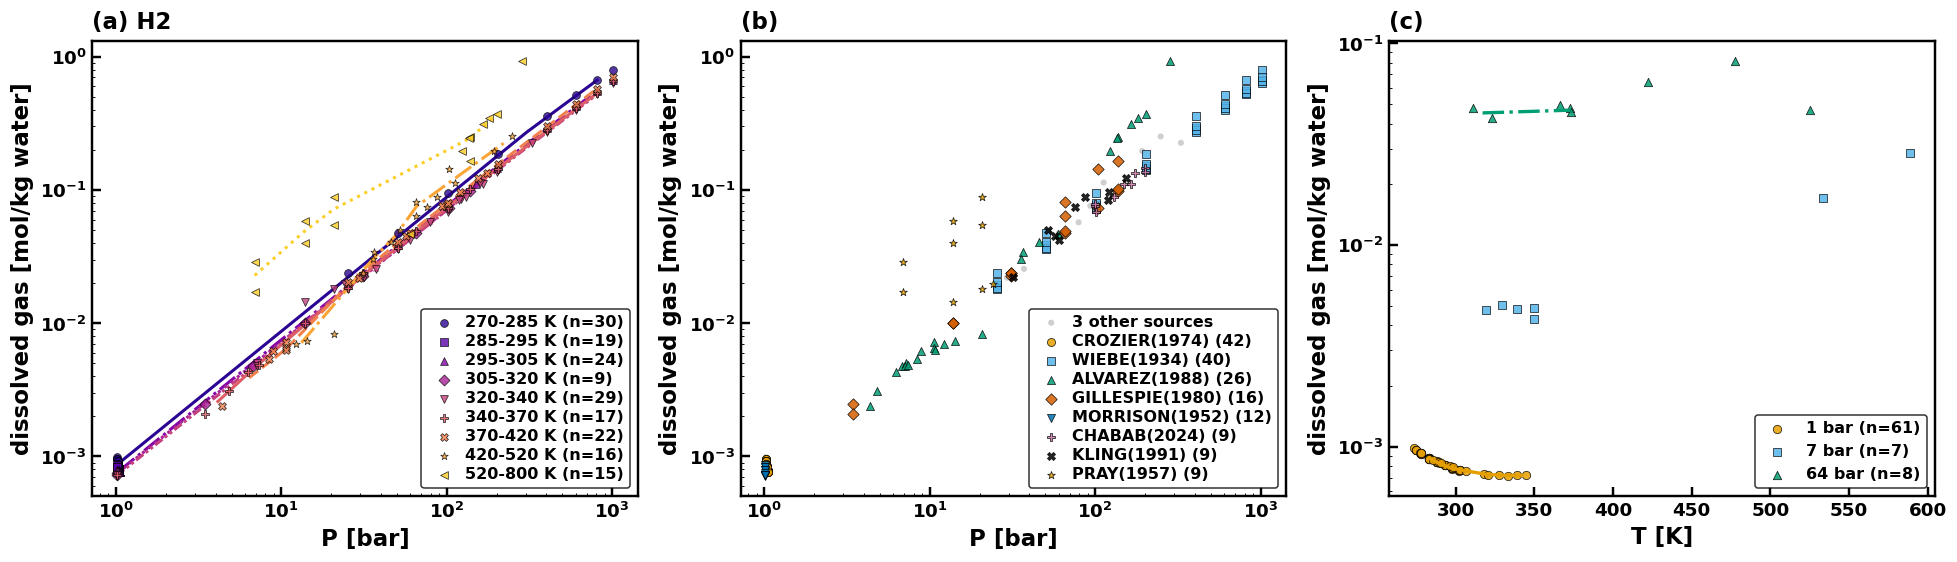

In [6]:
gas_figure("h2")

## N2 in water

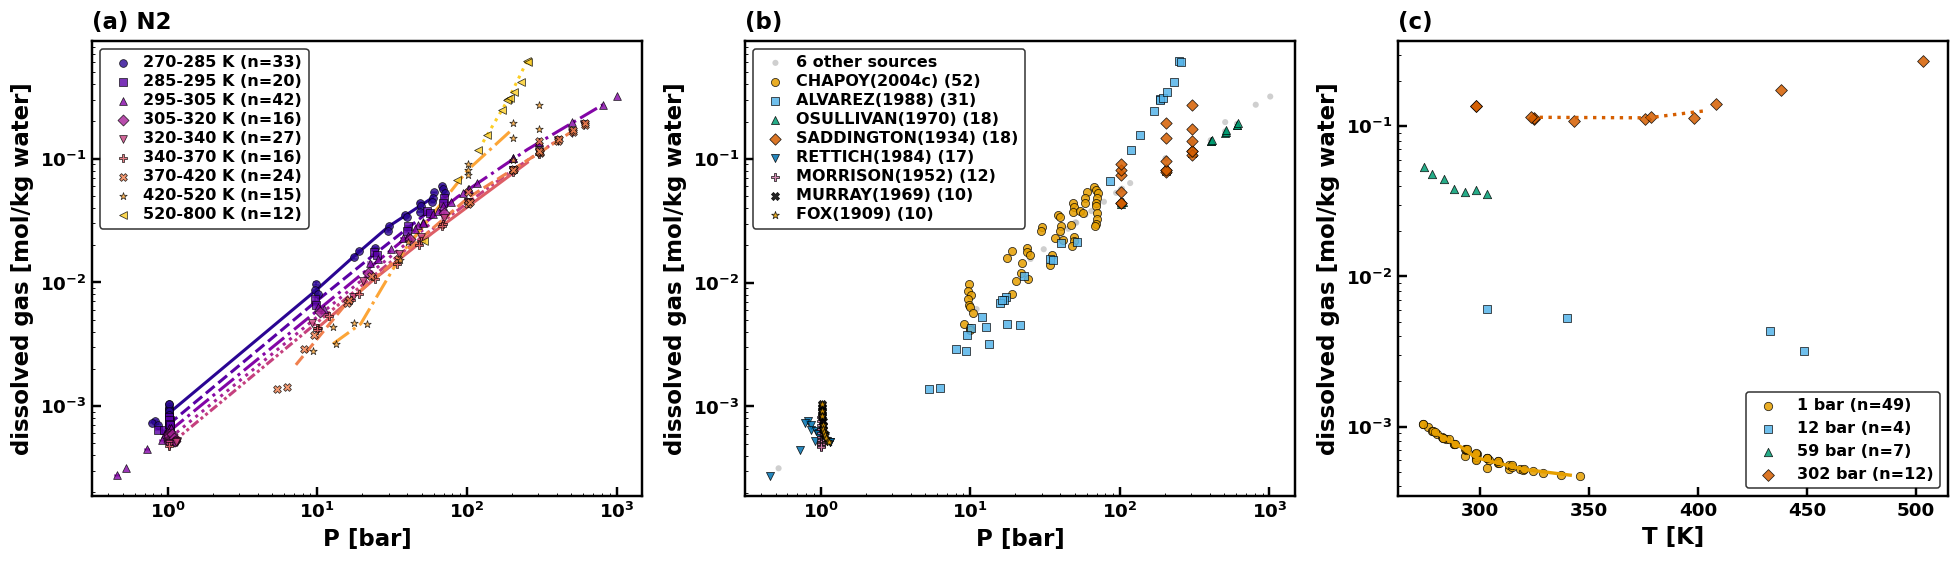

In [7]:
gas_figure("n2")

## O2 in water

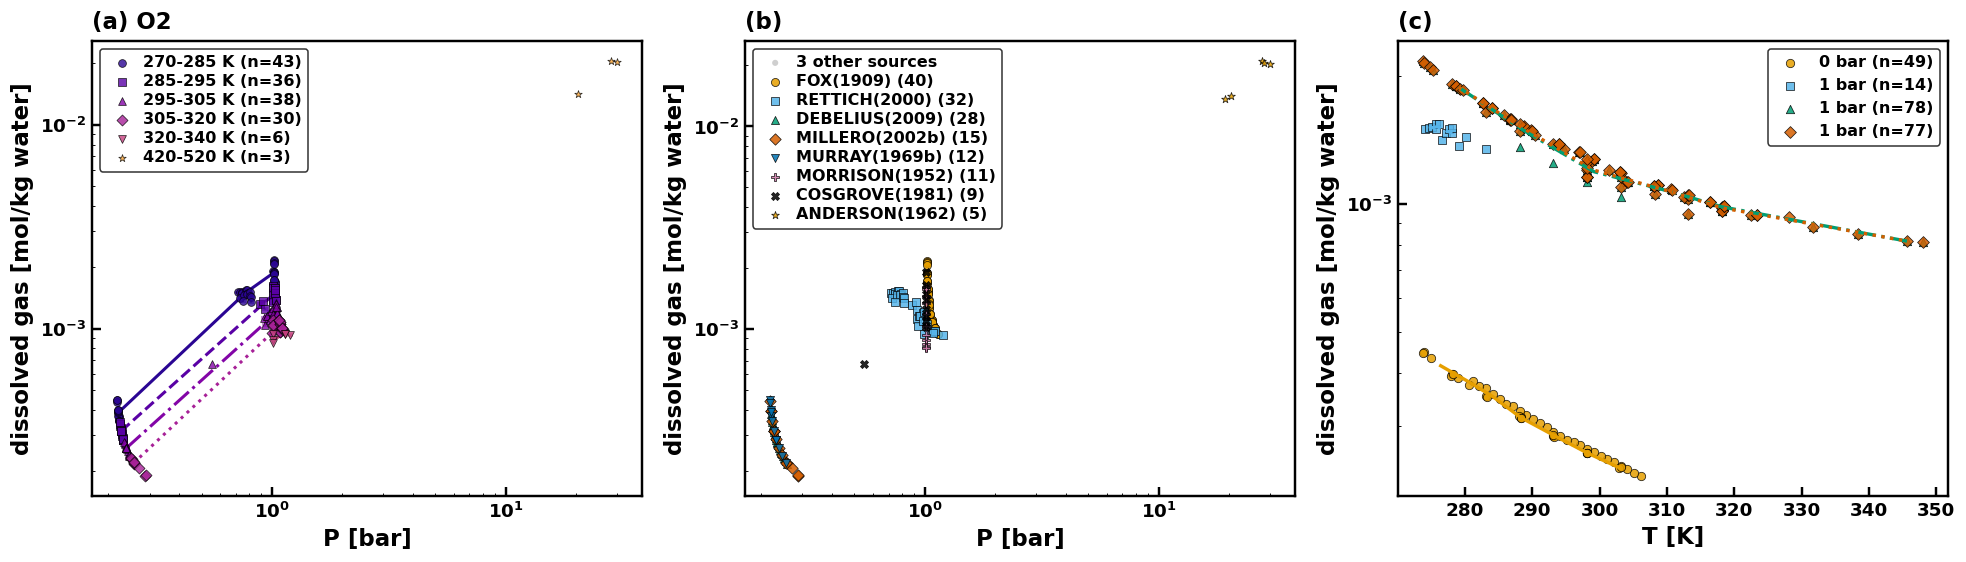

In [8]:
gas_figure("o2")

## C2H6 in water

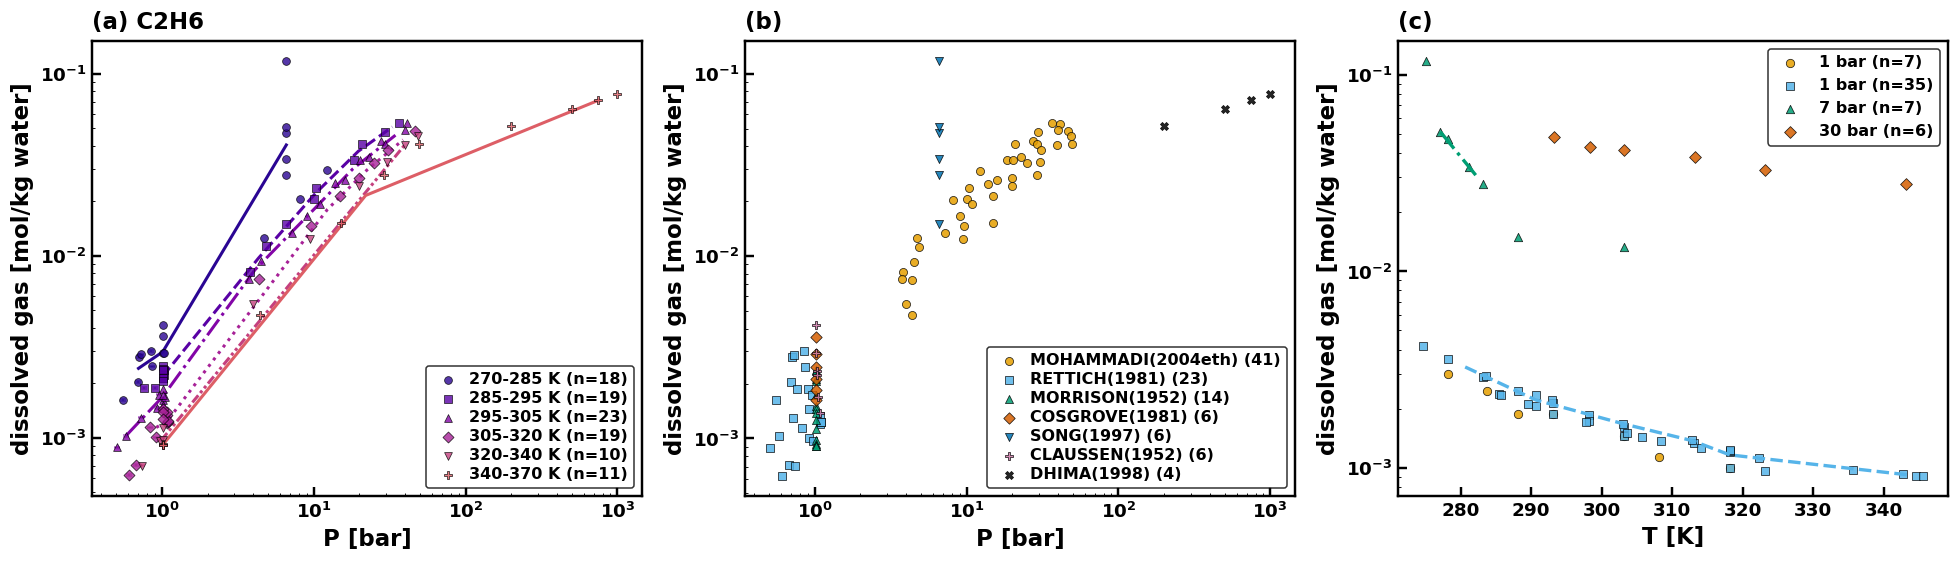

In [9]:
gas_figure("c2h6")

## C3H8 in water

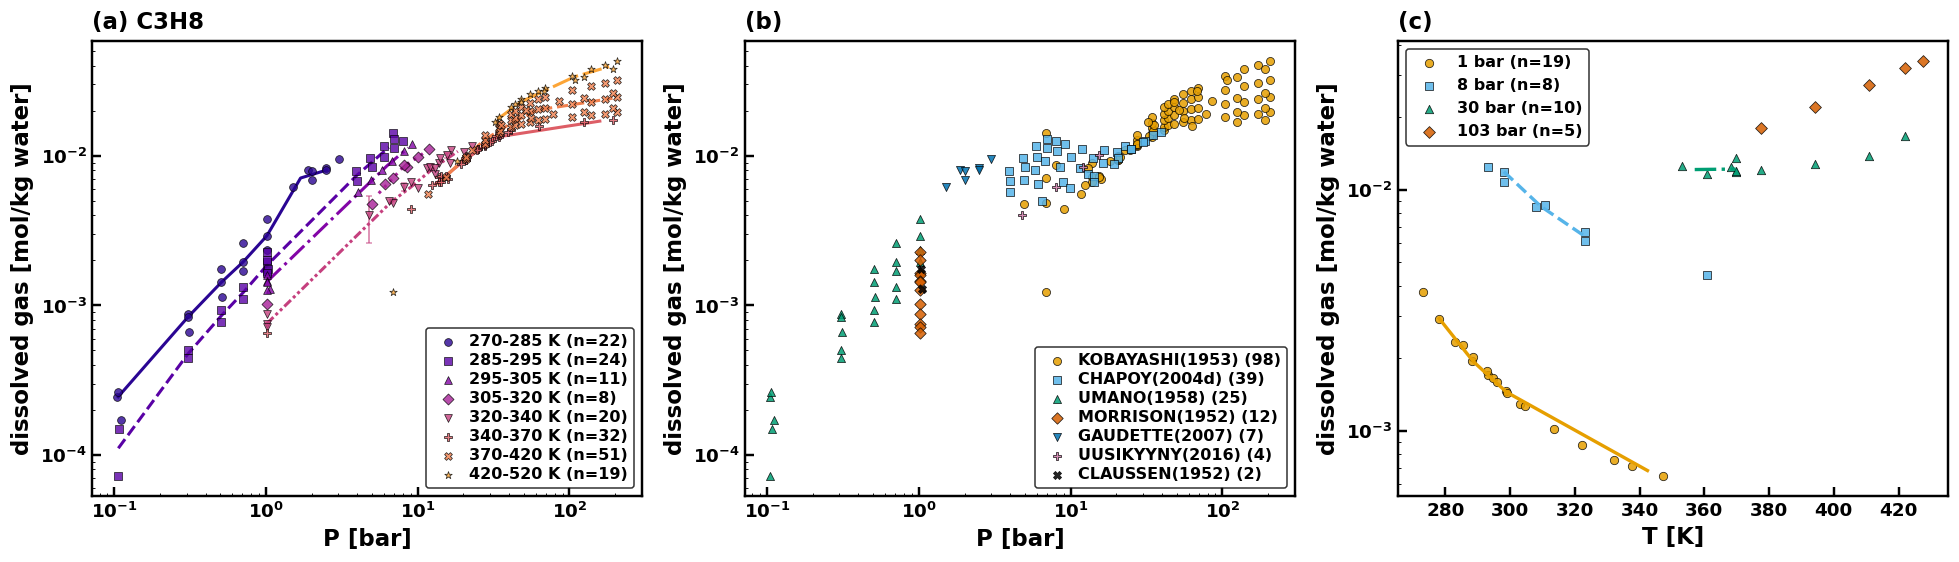

In [10]:
gas_figure("c3h8")

## Salting out

Solubility against the molality of NaCl (single-salt brines, `Na-Cl`), at fixed pressure windows, one colour/marker per temperature bin.
A gas dissolves less in a brine than in water; the slope in log space is the Setschenow-type trend. Spread at one molality and colour is
the difference between datasets and temperatures within a bin.

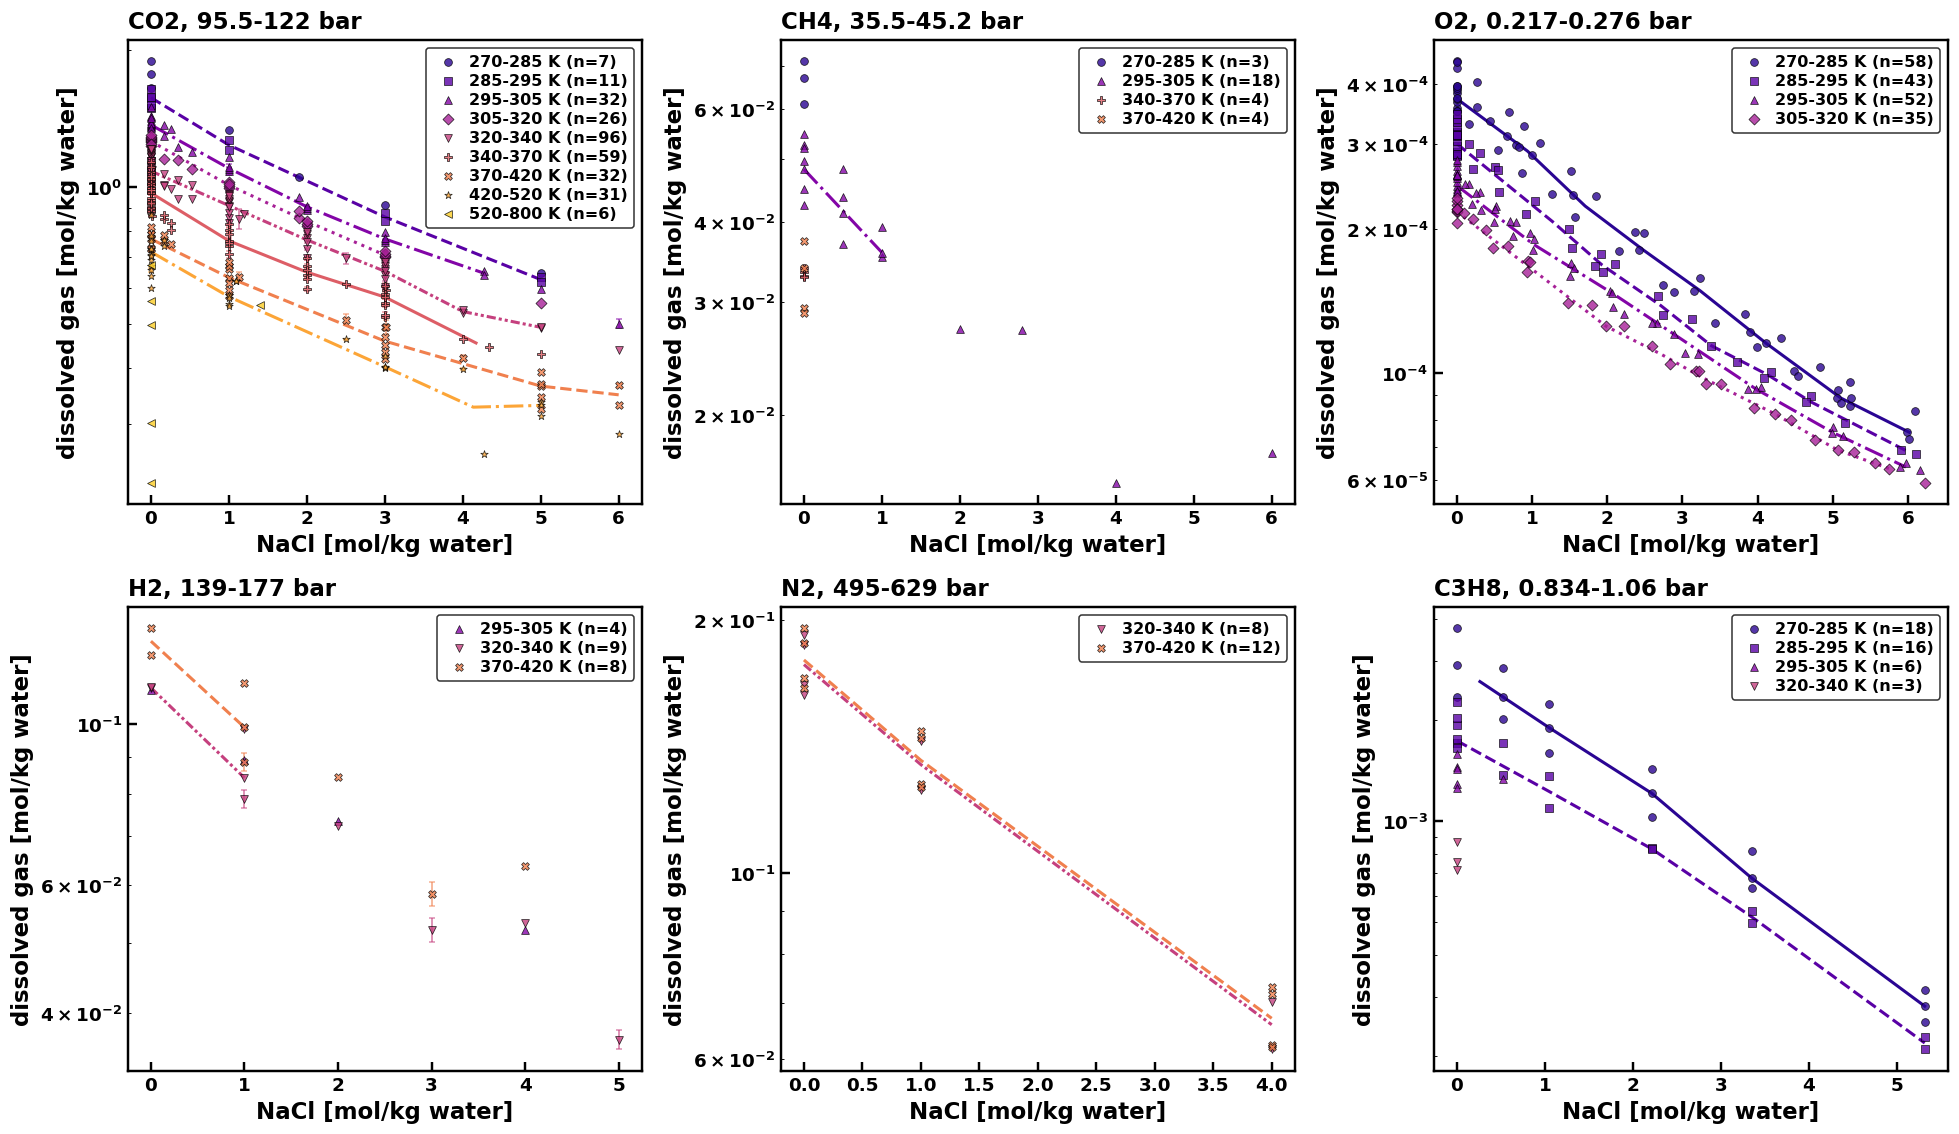

In [11]:
nacl = sol[sol.salt_system.isin(["water", "Na-Cl"])].copy()
nacl["m_NaCl"] = nacl.m_Na

def best_window(g, width=0.12):
    """Pressure window (log-centred, +-12 %) that holds the most NaCl-brine points at the most molalities."""
    b = g[g.m_NaCl > 0]
    best = (0, None)
    for pc in np.geomspace(max(b.P_bar.min(), 0.1), b.P_bar.max(), 60):
        w = b[(b.P_bar >= pc * (1 - width)) & (b.P_bar <= pc * (1 + width))]
        score = len(w) * w.m_NaCl.round(1).nunique()
        if score > best[0]: best = (score, (pc * (1 - width), pc * (1 + width)))
    return best[1]

fig, axes = plt.subplots(2, 3, figsize=(18, 10.5))
for ax, gas in zip(axes.ravel(), ["co2", "ch4", "o2", "h2", "n2", "c3h8"]):
    g = nacl[nacl.gas == gas]
    win = best_window(g) if (g.m_NaCl > 0).sum() >= 5 else None
    if win is None:
        ax.text(0.5, 0.5, "too few NaCl-brine points", transform=ax.transAxes, ha="center"); V.lab(ax, "", "", V.GAS_LABEL[gas]); continue
    w = g[(g.P_bar >= win[0]) & (g.P_bar <= win[1])]
    V.isotherms(ax, w, x="m_NaCl", y="value", logx=False, logy=True, trend_line=True)
    V.lab(ax, "NaCl [mol/kg water]", "dissolved gas [mol/kg water]", f"{V.GAS_LABEL[gas]}, {win[0]:.3g}-{win[1]:.3g} bar")
plt.tight_layout(); plt.show()

## Mixed salts and other salts

CO2 near 323 K and 100-250 bar against ionic strength, by salt system: how much of the salt effect is carried by ionic strength alone?

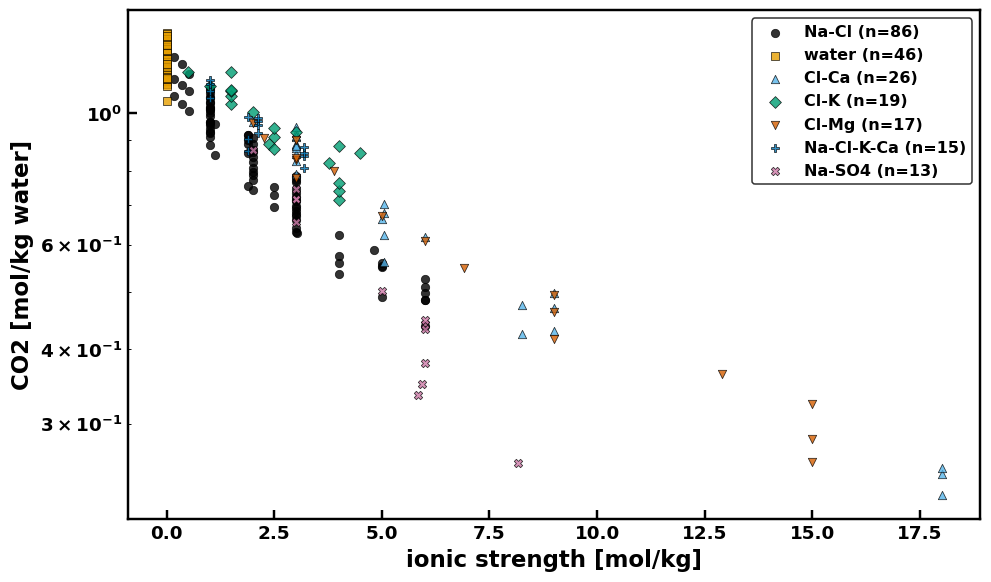

In [12]:
g = sol[(sol.gas == "co2") & sol.T_K.between(318, 328) & sol.P_bar.between(90, 260) & (sol.total_molality >= 0)].copy()
g["I"] = g.ionic_strength
systems = g.salt_system.value_counts().head(7).index
fig, ax = plt.subplots(figsize=(10, 6))
for k, s in enumerate(systems):
    w = g[g.salt_system == s]
    ax.scatter(w.I, w.value, s=30, color=V.WONG[k % 7], marker=V.MARKERS[k], edgecolor="black", linewidth=0.5, alpha=0.8, label=f"{s} (n={len(w)})")
ax.set_yscale("log"); ax.legend(loc="best"); V.lab(ax, "ionic strength [mol/kg]", "CO2 [mol/kg water]"); plt.show()